# Supervised Machine Learning - Key Techniques

So far, we’ve explored a range of popular supervised models and seen how Scikit-Learn’s unified API makes it almost effortless to define, train, and deploy them. In fact, most Scikit-Learn workflows boil down to three simple steps:

```python
# 1. Instantiate your model
my_model = ScikitLearnModel(parameter1, parameter2, ...)

# 2. Fit it to your data
my_model.fit(X, y)

# 3. Generate predictions
my_model.predict(X_new)
```

But real-world success demands much more than knowing these commands! Developing true expertise requires a lot of hands-on experience: be prepared to spend significant time exploring datasets, engineering features, and tuning hyperparameters before you intuitively understand what approaches work and why. 

Whether through online tutorials, Kaggle competitions or, ideally, practical projects from your studies, your job, or even self-directed challenges, every experiment builds the depth of insight you need.

Equally important is mastering fundamental concepts in model training and evaluation. Grasping techniques like cross-validation, recognizing and avoiding overfitting or underfitting, selecting the right performance metrics, and properly preprocessing data are all essential to turning code into reliable predictions. In this chapter, we’ll guide you through those critical ideas so that when you next invoke fit() and predict(), you’ll know better what to look for — and how to steer it toward your goals.

## Model Evaluation

Model evaluation is crucial in understanding the performance of machine learning algorithms. Beyond the basic metrics introduced previously like accuracy and confusion matrices, it is very useful to know more about additional metrics to capture different aspects of model performance comprehensively.

First off, there is not a simple general answer to which metric is the best. This largely depends on the type of data, the type of model, and the actual question we want to answer with our model. Let's take an example of a use case where we want to predict fraudulent phone calls from data such as call duration, call origin, time, etc. This data could easily have many more regular calls than fraudulent calls, let's assume we have 99,000 non-fraudulent calls and 1,000 fraudulent calls in the data. We call this **biased data**, and handling this correctly is one of the most common challenges in machine learning. 

We now train a machine learning model, say a decision tree, to predict if a phone call is fraudulent or not. What would be a good accuracy for such a model?

If you think about this for a moment (please do!), then you might realize that it is not easy to define what a *good* accuracy value is. For this reason, you should never only present an accuracy value without context! Always at least ask what would be achievable with little effort and compare to this **baseline**. In the phone call example, I can easily come up with a toy "model" that will always predict non-fraudulent. What would the accuracy of this toy model be?

The accuracy is the fraction of correct predictions, and if I simply label all calls as non-fraudulent I would be correct in $99\%$ of the cases. So, my accuracy becomes $0.99$. Without any context, that might look like a good result, but this baseline example makes clear that a model with such an accuracy value is not at all impressive on the given task.

The confusion matrix we used earlier will do much better here because this will also reveal that our toy model does not discover any of the fraudulent calls (which makes it completely useless for any application...).


### Detailed Model Evaluation Metrics (classification)
Here are a few of the most commonly used metrics to evaluate classification models.

#### 1. Confusion Matrix

A confusion matrix is an $N \times N$ matrix used for evaluating the performance of a classification model, where N is the number of target classes. The matrix compares the actual target values with those predicted by the machine learning model, providing insight into the types of errors made by the classifier.

- Elements:

  - **True Positives (TP)**: Correct positive predictions.
  - **False Positives (FP)**: Incorrectly predicted positives (Type I error).
  - **True Negatives (TN)**: Correct negative predictions.
  - **False Negatives (FN)**: Incorrectly predicted negatives (Type II error).

In the fraud detection example, a false negative would be more dangerous and costly than a false positive. A high number of FN means many fraudulent calls are not being detected. Conversely, while FP might cause some inconvenience (e.g., blocking legitimate calls), it is preferable over missing actual frauds.

```{figure} ../images/fig_classification_metrics_sketch.png
:name: fig_classification_metrics

The confusion matrix is a good way to quickly display and assess the true positive value (TP), the true negative value (TN) as well as the false positives (FP) and false negatives (FN). Based on those numbers different standard metrics to evaluate a model are computed such as  accuracy, recall, specificity, and precision.
```

#### 2. Precision and Recall

Precision and recall are metrics that provide more insight into the accuracy of positive predictions and the classifier's ability to recover all relevant instances, respectively.

**Precision (Positive Predictive Value)**:  
The ratio of correctly predicted positive observations to the total predicted positives.

$$
\mathrm{Precision} = \frac{TP}{TP + FP}
$$

High precision indicates a low false positive rate, which is crucial in scenarios where the cost of a false positive is high, such as in email spam classification.

**Recall (Sensitivity, True Positive Rate)**:  
The ratio of correctly predicted positive observations to all observations in actual class.

$$
\mathrm{Recall} = \frac{TP}{TP + FN}
$$

High recall is vital in medical scenarios or fraud detection, where failing to detect an anomaly can have severe consequences.

#### 3. F1 Score

The F1 Score is the weighted average of Precision and Recall. Therefore, this score takes both false positives and false negatives into account. It is particularly useful when the class distribution is uneven (biased data).


$$
F_1 = 2 \cdot \frac{\mathrm{Precision} \cdot \mathrm{Recall}}{\mathrm{Precision} + \mathrm{Recall}}
$$
  
The F1 score is an excellent measure to use if you need to seek a balance between Precision and Recall and there is an uneven class distribution (as in the case of your fraudulent vs. non-fraudulent calls scenario).

#### 4. Accuracy

As previously discussed, accuracy is the ratio of correctly predicted observations to the total observations and can be misleading in the presence of an imbalanced dataset.

$$
\mathrm{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$


### Detailed Model Evaluation Metrics (Regression)
Here are a few of the most commonly used metrics to evaluate regression models.

#### 1. Mean Absolute Error (MAE)

MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It’s the average over the test sample of the absolute differences between prediction and actual observation where all individual differences have equal weight.

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|
$$

where $y_i$ are the actual values and $\hat{y}_i$ are the predicted values.

#### 2. Mean Squared Error (MSE)

MSE is like MAE but squares the difference before summing them all instead of using the absolute value. This has the effect of heavily penalizing larger errors.

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2
$$

MSE is more sensitive to outliers than MAE and tends to emphasize larger differences.


There are many more metrics available, such as `RMSE` or `R-squared`, but we will not cover them in this course.

In Scikit-Learn all those scores are already implemented:
```python
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, confusion_matrix, f1_score

# Assuming y_true and y_pred are available
print("Accuracy:", accuracy_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("MSE:", mean_squared_error(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))
```

## Training and Testing Strategies

Developing a robust machine learning model involves more than just selecting the right algorithm. Equally crucial are the strategies employed for training and testing the model. These strategies are fundamental to ensuring that the model performs well not just on the data it was trained on, but also on new, unseen data. This section explores various methodologies for dividing your dataset, training your models, and validating their performance to ensure reliability and accuracy in predictions.

### Splitting Your Data: Training, Validation, and Test Sets

**1. Train-Test Split**
The most basic approach to training and testing a machine learning model is to divide your data into two sets: the training set and the test set. The typical ratios are 70% for training and 30% for testing, but these can vary depending on the dataset size.

- **Purpose**: Ensures that the model can be evaluated on unseen data.

- Method:

  ```python
  from sklearn.model_selection import train_test_split
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
  ```

**2. Train-Validation-Test Split**
When tuning hyperparameters or making decisions about model architecture, it’s crucial to have a third split: the validation set.

- **Purpose**: Allows for model tuning without touching the test set, thereby keeping the test set as a truly unseen dataset for final model evaluation.
- **Implementation Tip**: Reserve a part of the training set for validation or use techniques like cross-validation.

### Cross-Validation: Enhancing Model Validation

Cross-validation is a robust method for estimating the effectiveness of your model, which is especially useful when dealing with limited data.

A **k-Fold Cross-Validation** means that the dataset is divided into 'k' smaller sets. The model is trained on 'k-1' of these folds, with the remaining part used as the test fold. This process is repeated 'k' times, with each of the 'k' folds used exactly once as the test set.

Using Scikit-Learn this can be realized like this:
```python
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, random_state=42, shuffle=True)
scores = cross_val_score(model, X, y, cv=kf)
average_score = scores.mean()
```

A variation of a k-fold is the **stratified K-Fold** that is used for highly imbalanced classes. It ensures that each fold of the dataset has the same proportion of examples in each class as the complete set.


```{figure} ../images/fig_cross_validation_training.png
:name: fig_cross_validation_training

Illustration of a model training workflow using cross-validation to find the best hyperparameters. The displayed workflow also contains an additional first split into train and test set, a common best practice to avoid any form of overfitting. Under certain circumstances, however, it is also possible to skip this split and only work with k-fold cross-validation, in particular for very small datasets.
```

### Advanced Techniques for Unbalanced Data

When dealing with imbalanced datasets, traditional training and testing strategies may not suffice, as they might lead to models biased towards the majority class.
Common strategies to work with highly imbalanced data are:

- **Oversampling the Minority Class**: Increasing the number of instances in the minority class by duplicating them to prevent the model from being biased toward the majority class.
- **Undersampling the Majority Class**: Reducing the number of instances in the majority class to balance the dataset.
- **Synthetic Data Generation**: Techniques like SMOTE (Synthetic Minority Over-sampling Technique) generate synthetic samples rather than duplicating existing samples to provide more generalization.

### Putting It All Together

Choosing the right training and testing strategies is crucial for building a reliable model. The key is to simulate a real-world scenario as closely as possible, where the model will make predictions on unseen data. By employing robust validation techniques like cross-validation and adjusting training strategies based on the data's characteristics, such as imbalance, one can significantly enhance model accuracy and reliability.

Implementing these strategies effectively allows for comprehensive assessment and refinement of models, ensuring they perform well across different datasets and hold up to the rigors of real-world application.


### Beyond this course:
Here, we did the sampling, that is the selection of data points, for either training or testing, fully randomly. In many real-world cases, however, the situation can be more complex. For instance, we might have many medical observations in a dataset with sometimes multiple entries for the same patient. In such a case we would have to split the data by patient and not fully randomly (see, for instance, here: {cite}`tougui2021impact`). In other cases, we will have strong biases and we would often like to compensate for this. For example, to avoid that -purely by chance- a certain population or class is not well represented in a certain data split. The process to compensate for this is called **stratification**.

## Nice-to-have: Scikit-learn Pipeline

The scikit-learn Pipeline is an essential tool for encapsulating your entire workflow in machine learning model construction. The purpose of a Pipeline is to assemble several steps that can be cross-validated together while setting different parameters. It helps in maintaining the sequence of transformations and ensuring that all steps in the process are carried out consistently (see {numref}`fig_scikit_pipeline`). This makes the model building process cleaner, easier to manage, and repeatable.

**Key Features:**
- **Automation of Workflow**: Pipeline automates the process of applying the same sequence of transformations for fitting and predicting data. For example, scaling data, extracting features, and then training a model.
- **Ease of Experimentation**: By defining a set of steps, Pipelines allow for easy experimentation with different processing or learning steps.
- **Prevention of Data Leakage**: Pipelines help in preventing data leakage by ensuring that data transformations are learned from training data inside the cross-validation loop and applied to the validation data.

**Example Usage**:
```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# Create a pipeline with a scaler, PCA dimensionality reduction, and logistic regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('logistic_regression', LogisticRegression())
])

# Now the pipeline can be used like a single model
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
```

```{figure} ../images/fig_scikit_pipeline.png
:name: fig_scikit_pipeline

In addition to the "normal" workflow to train a model directly (**A**), the Scikit-Learn Pipeline allows combining multiple processing steps into a `Pipline` object. This can then be used just like a single model, for instance by running `.fit()` or `.predict()`.
```

## Hands-on Example: Obesity prediction

We will here work with an [`Obesity Levels Dataset`](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition) {cite}`Palechor2019DatasetFE` which was downloaded from the [UCI archive](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition).

This dataset comprises data for predicting obesity levels in individuals from Mexico, Peru, and Colombia, utilizing information about their dietary habits and physical condition. It includes 17 attributes across 2111 records. Each record is categorized under the class variable NObesity (Obesity Level), which facilitates the classification of data into categories such as Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II, and Obesity Type III. Only 23% of the data was sourced directly from individuals through a web-based platform. The larger part of the dataset, 77%, was synthetically generated using the Weka software and the SMOTE filter to augment the data diversity.

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sb

### Data Inspection & Cleaning

In [2]:
filename = "../datasets/obesity_dataset.csv"
data = pd.read_csv(filename)

In [3]:
data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


Our future labels will be the obesity labels:

In [4]:
data.NObeyesdad.value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

### Data Processing

For training machine learning models, at least many types of them, the data has to be present in numerical from. For models such as decision trees this could in principle be skipped, but let's convert the data to be sure we can select different models later on.

In [5]:
mask = data.describe(include="all").loc["unique"] == 2
binary_columns = data.columns[mask]
data[binary_columns]

,Gender,family_history_with_overweight,FAVC,SMOKE,SCC
0,Female,yes,no,no,no
1,Female,yes,no,yes,yes
2,Male,yes,no,no,no
3,Male,no,no,no,no
4,Male,no,no,no,no
...,...,...,...,...,...
2106,Female,yes,yes,no,no
2107,Female,yes,yes,no,no
2108,Female,yes,yes,no,no
2109,Female,yes,yes,no,no


In [6]:
data[binary_columns] = data[binary_columns].replace({'no': 0, 'yes': 1})

#### Split Data and Labels
The column `NObeyesdad` becomes our label `y` and will hence be removed from the data `X`.

In [7]:
y = data.NObeyesdad
X = data.drop(["NObeyesdad"], axis=1)

X = pd.get_dummies(X) #, prefix='', prefix_sep='')
X = X.drop(["Gender_Male"], axis=1)  # not necessary, because here it is either Male or Female
X.head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Female,family_history_with_overweight_0,...,SCC_1,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,True,False,...,False,False,False,False,True,False,False,False,True,False
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,True,False,...,True,False,False,True,False,False,False,False,True,False
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,False,False,...,False,False,True,False,False,False,False,False,True,False
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,False,True,...,False,False,True,False,False,False,False,False,False,True
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,False,True,...,False,False,False,True,False,False,False,False,True,False


In [8]:
X.columns

Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE',
       'Gender_Female', 'family_history_with_overweight_0',
       'family_history_with_overweight_1', 'FAVC_0', 'FAVC_1', 'CAEC_Always',
       'CAEC_Frequently', 'CAEC_Sometimes', 'CAEC_no', 'SMOKE_0', 'SMOKE_1',
       'SCC_0', 'SCC_1', 'CALC_Always', 'CALC_Frequently', 'CALC_Sometimes',
       'CALC_no', 'MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike',
       'MTRANS_Public_Transportation', 'MTRANS_Walking'],
      dtype='str')

#### Inspect Correlations in the Data
We could for instance have a look at features that show high correlations (positive OR negative) with one of our labels. This can give a first idea of which features might be relevant for later predictions.
This step is optional, though, but it hopefully shows that different data science techniques can be applied in combinations.


<Axes: >

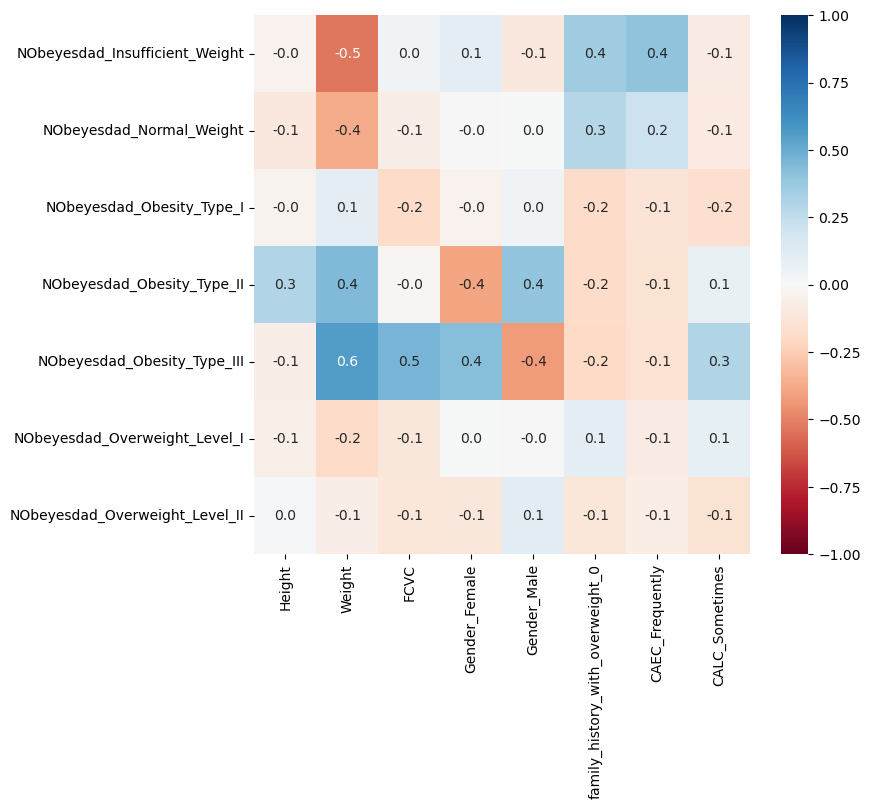

In [9]:
data_one_hot = pd.get_dummies(data)
label_columns = [x for x in data_one_hot.columns if "NObeyesdad" in x]

# Select columns with correlations with at least one label which is > 0.3
correlations_with_targets = data_one_hot.corr()
max_correlations = correlations_with_targets.loc[label_columns].max().abs()
mask = (max_correlations > 0.3) & (max_correlations < 1)


fig, ax = plt.subplots(figsize=(8, 7))

sb.heatmap(correlations_with_targets.loc[label_columns, mask],
           annot=True,  fmt=".1f",
           cmap="RdBu",
           vmin=-1, vmax=1)

#### Train/Test split

As done before, we will do a single split to divide the data into a training set and a test set. We will also apply the alternative, cross-correlation, later in this section.

In [10]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [11]:
# Let's check the outcome dimensions
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1583, 30), (528, 30), (1583,), (528,))

### Train a k-NN Classifier
We will here use a k-NN classifier for a first test. As introduced in {ref}`ch_ml_algorithms_1`, this algorithm requires data that is numerical and scaled. The scaling can be seen as part of the model, and we can use Scikit-learn pipelines to combine both steps:

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=7)),
])

In [13]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30

In [14]:
from sklearn.metrics import confusion_matrix

predictions = pipe.predict(X_test)

C:\Users\flori\anaconda3\envs\data_science\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


### Evaluate the Model
As introduced above, me have the choice between several different metrics to evalute our model. First, we look at accuracy, precision, recall, and f1-score.

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_train = pipe.predict(X_train)
y_pred_test = pipe.predict(X_test)

# Metrics for the training set
accuracy_train = accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train, average='weighted')  # using 'weighted' to handle class imbalance
recall_train = recall_score(y_train, y_pred_train, average='weighted')
f1_train = f1_score(y_train, y_pred_train, average='weighted')

print("Training Metrics:")
print(f"Accuracy: {accuracy_train:.4f}")
print(f"Precision: {precision_train:.4f}")
print(f"Recall: {recall_train:.4f}")
print(f"F1 Score: {f1_train:.4f}")

# Metrics for the test set
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, average='weighted')
recall_test = recall_score(y_test, y_pred_test, average='weighted')
f1_test = f1_score(y_test, y_pred_test, average='weighted')

print("\nTest Metrics:")
print(f"Accuracy: {accuracy_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall: {recall_test:.4f}")
print(f"F1 Score: {f1_test:.4f}")


Training Metrics:
Accuracy: 0.8358
Precision: 0.8339
Recall: 0.8358
F1 Score: 0.8338

Test Metrics:
Accuracy: 0.8030
Precision: 0.7976
Recall: 0.8030
F1 Score: 0.7981


Instead of computing all of them individually using Scikit-Learn functions, we can also use pre-assembled functions such as `classification_report`:

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test))

                     precision    recall  f1-score   support

Insufficient_Weight       0.83      0.91      0.87        78
      Normal_Weight       0.64      0.54      0.58        69
     Obesity_Type_I       0.79      0.77      0.78        86
    Obesity_Type_II       0.84      0.99      0.91        73
   Obesity_Type_III       0.98      0.99      0.98        88
 Overweight_Level_I       0.78      0.68      0.72        68
Overweight_Level_II       0.68      0.68      0.68        66

           accuracy                           0.80       528
          macro avg       0.79      0.79      0.79       528
       weighted avg       0.80      0.80      0.80       528



#### Confusion matrix
While those metrics have all their merits, often one of the most informative evaluation approaches for classification problems remains the confusion matrix. This not only gives a sense of the overall performance of a model, but also indicates which classes are often confused and hence seemingly difficult for the model to distinguish.

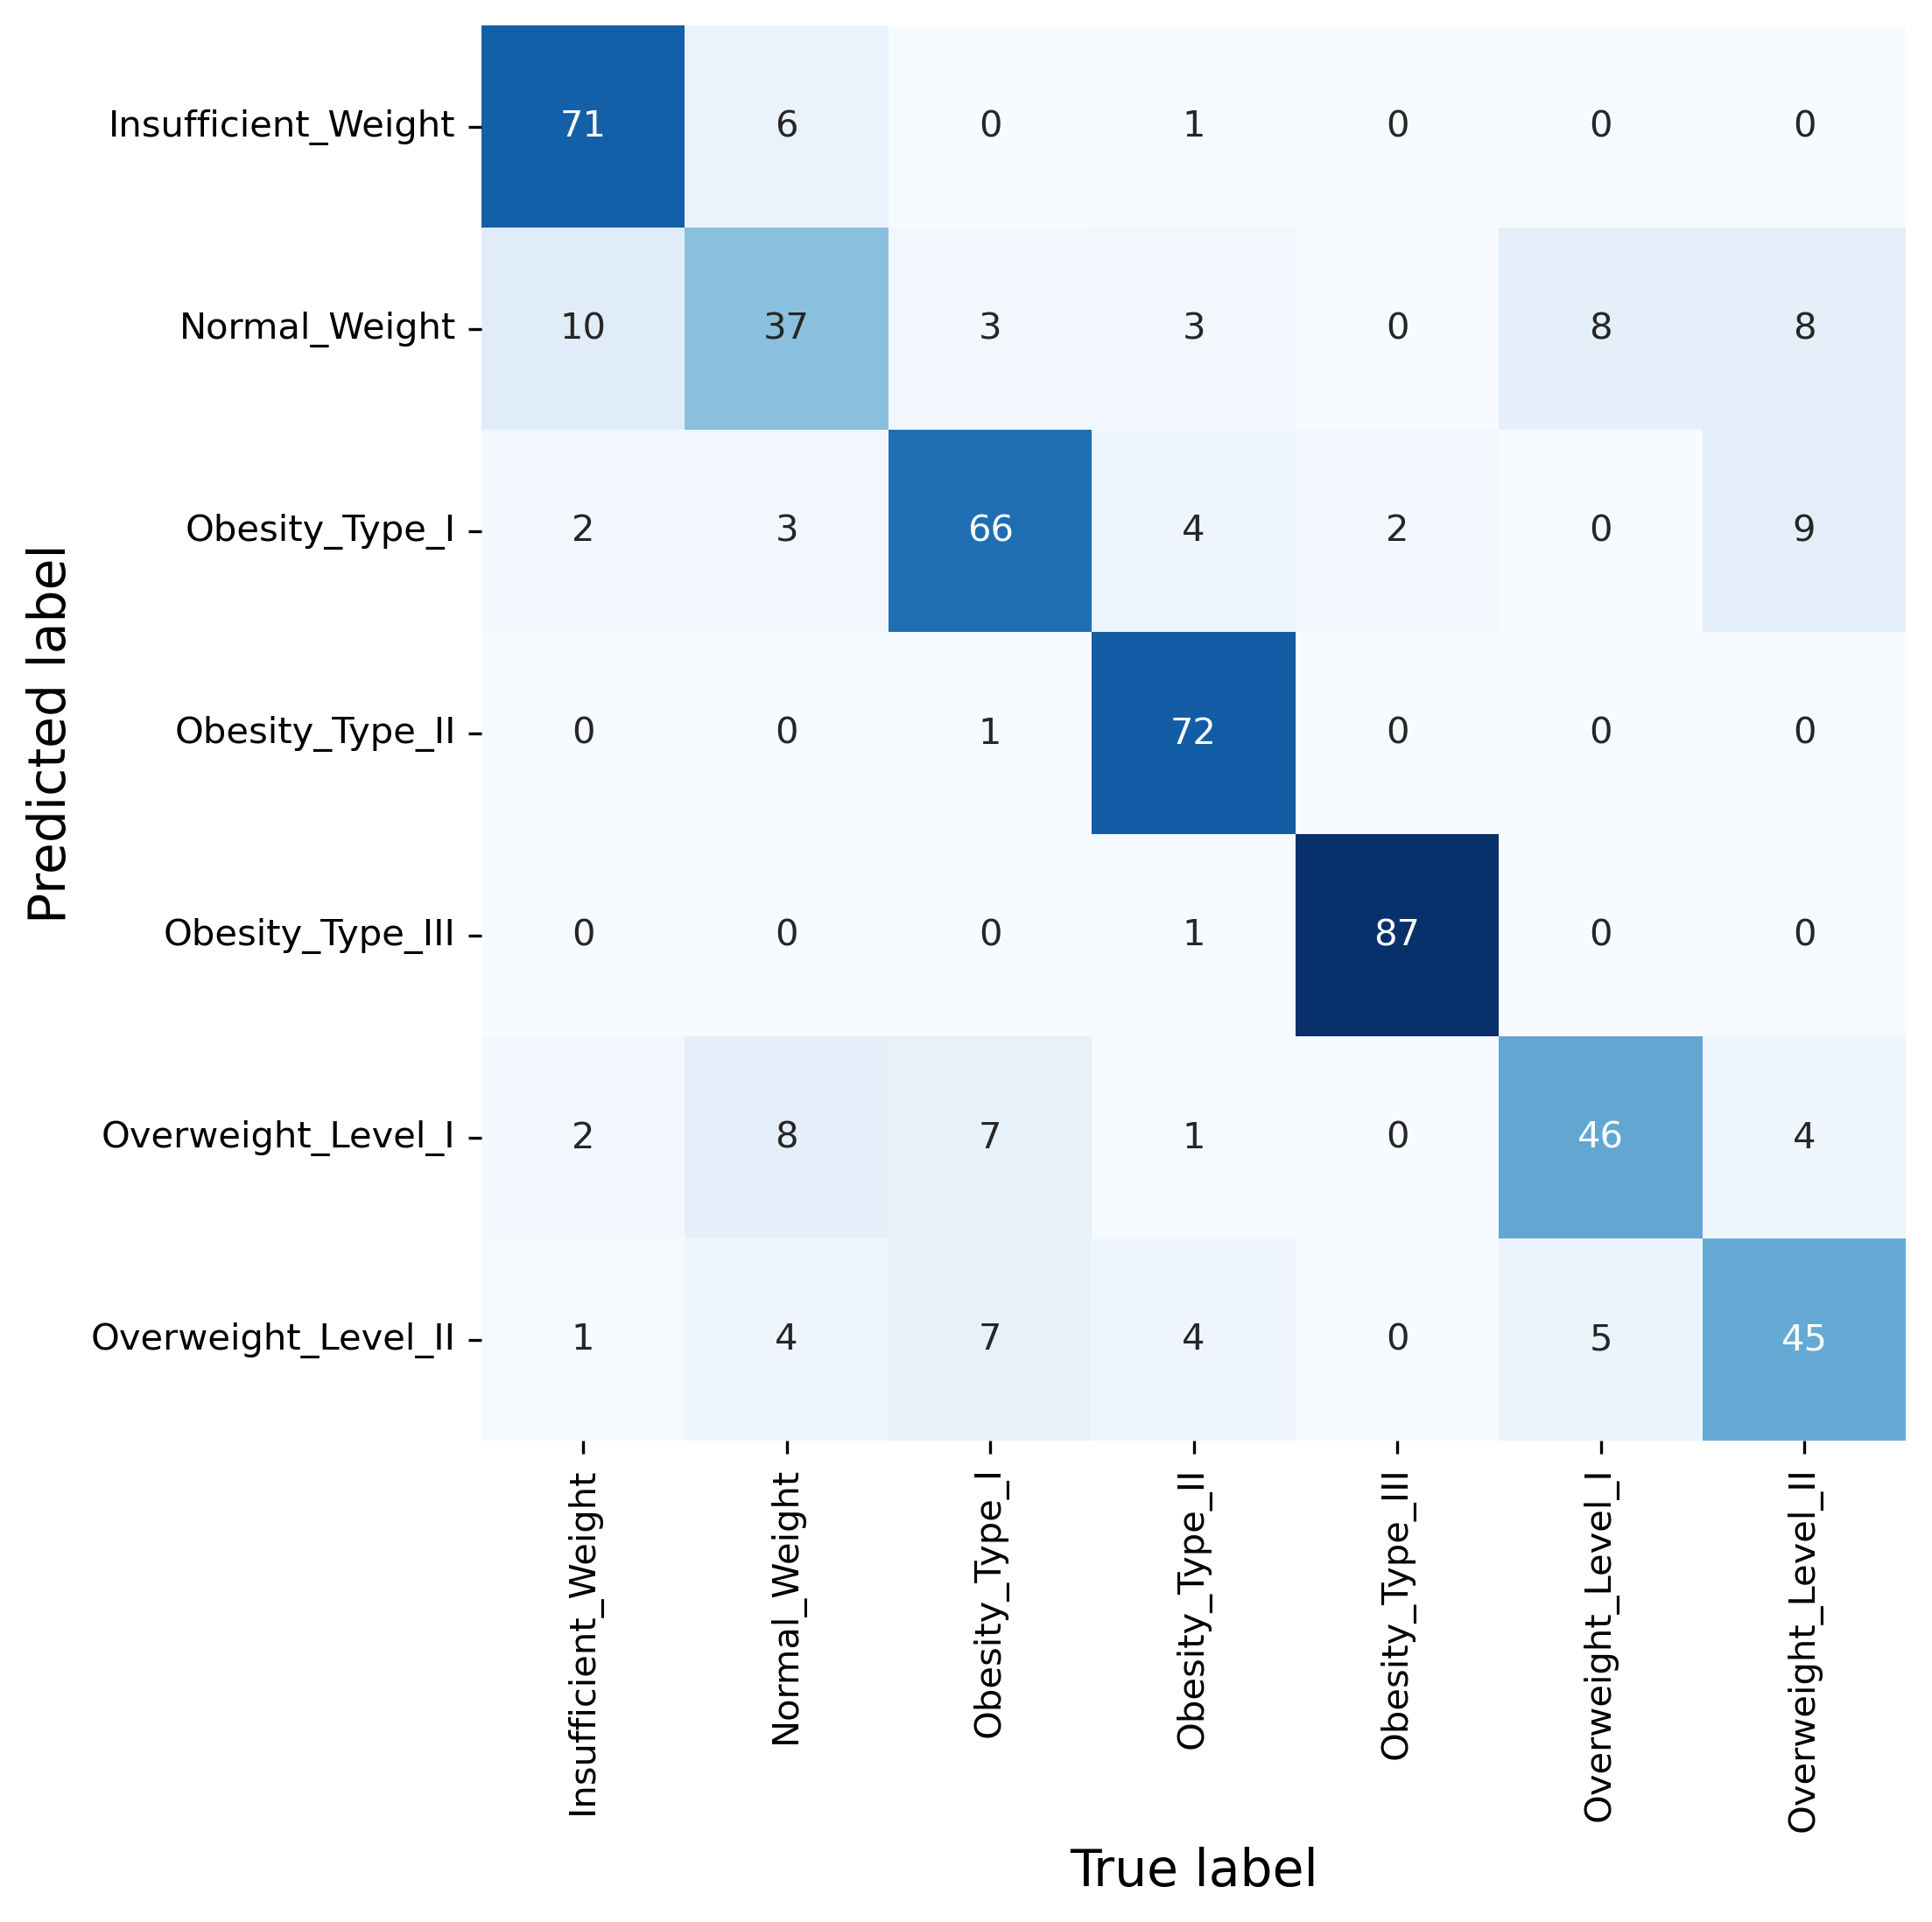

In [17]:
fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

sb.heatmap(confusion_matrix(y_test, predictions),
           annot=True, cmap="Blues", cbar=False, fmt=".0f",
           xticklabels=pipe.classes_,
           yticklabels=pipe.classes_)
ax.set_xlabel("True label", fontsize=14)
ax.set_ylabel("Predicted label", fontsize=14)
plt.show()

### Hyperparameter Search
Although we used a simple k-NN model here, the results look OK-ish at first sight. But here are some questions for you:
- How do we know if this is just OK, or good, or excellent?
- How can we improve our model further? And is this even possible?

---

The answer is not always simple.

To judge whether or not a model is doing very well, we always need to have some references for comparison.
In the case we see here -and unlike the fraudulent phone call example in the beginning of this section- it is much harder to come up with a simple toy model here. A random model, for instance, would certainly do much worse.

So it is not all bad but also not making perfect predictions.
But is a perfect model even possible? And how can we optimize our model besides manually trying many different variations?

We can start with the model optimization because this is more straightforward.
At least for cases like the one at hand, where computation time is no restriction because the model and dataset are relatively small and simple. In such cases it is usually good enough to just run a systematic parameter search.

## Systematic Parameter Search

Finding the optimal set of parameters for machine learning models can dramatically improve their performance. Scikit-learn offers tools like `GridSearchCV` and `RandomizedSearchCV` to automate the search for the best hyperparameters.

### Grid Search

- **GridSearchCV**: Performs an exhaustive search over specified parameter values for an estimator. Useful when we are looking for a small number of hyperparameters.

### Random Search

- **RandomizedSearchCV**: Can sample a given number of candidates from a parameter space with a specified distribution. More efficient than GridSearchCV when dealing with a large hyperparameter space or when we aim to reduce the computational burden.

We will here only do a simple grid search using Scikit-Learn's `GridSearchCV`. This works with any Scikit-Learn machine learning model, but also with `Pipeline` objects as displayed in {numref}`fig_scikit_gridsearch`.

```{figure} ../images/fig_scikit_gridsearch.png
:name: fig_scikit_gridsearch

Scikit-Learn's `GridSearchCV` combines a grid search for systematically comparing different parameter sets with a cross-validation approach. GridSearchCV objects again follow the Scikit-Learn workflow and can be trained using `.fit()`. 
```

In [18]:
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsClassifier()),  # we don't have to add any parameter here!
])

In [19]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(estimator=pipe,
                    param_grid={
                        "model__n_neighbors": [2, 3, 4, 5, 10, 15, 20]
                    },
                    cv=5,
                    return_train_score=True,
                    verbose=1,  # set to 2 if you want more information during the run
                   )

In [20]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 7 candidates, totalling 35 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scale', StandardScaler()),
                                       ('model', KNeighborsClassifier())]),
             param_grid={'model__n_neighbors': [2, 3, 4, 5, 10, 15, 20]},
             return_train_score=True, verbose=1)

After the training run the results for the different parameter settings can be compared.

In [21]:
results = pd.DataFrame(grid.cv_results_)
results.sort_values("rank_test_score").head(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.008354,0.000785,0.032765,0.003017,2,{'model__n_neighbors': 2},0.801262,0.839117,0.776025,0.803797,...,0.804167,0.020172,1,0.917062,0.921801,0.917062,0.910813,0.914759,0.916299,0.003575
1,0.009030,0.001091,0.037538,0.004634,3,{'model__n_neighbors': 3},0.801262,0.817035,0.763407,0.800633,...,0.799758,0.019502,2,0.887046,0.888626,0.895735,0.887135,0.891081,0.889924,0.003251
2,0.010817,0.001719,0.045460,0.004111,4,{'model__n_neighbors': 4},0.782334,0.798107,0.763407,0.781646,...,0.787757,0.016845,3,0.860979,0.860979,0.874408,0.862668,0.863457,0.864498,0.005048


We can also directly jump to the best performing parameter set:

In [22]:
grid.best_params_

{'model__n_neighbors': 2}

Or, we can have the `grid` object return the best performing model:

In [23]:
grid.best_estimator_

Pipeline(steps=[('scale', StandardScaler()),
                ('model', KNeighborsClassifier(n_neighbors=2))])

The grid search is usually just meant to find the most suitable parameters. Once we found them, we would train a new model using those settings:

In [24]:
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=2)),
])

In [25]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('scale', StandardScaler()),
                ('model', KNeighborsClassifier(n_neighbors=2))])

In the case of our k-NN model, this might not improve things much though...

In [26]:
y_pred_test = pipe.predict(X_test)

# Metrics for the test set
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, average='weighted')
recall_test = recall_score(y_test, y_pred_test, average='weighted')
f1_test = f1_score(y_test, y_pred_test, average='weighted')

print("\nTest Metrics:")
print(f"Accuracy: {accuracy_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall: {recall_test:.4f}")
print(f"F1 Score: {f1_test:.4f}")


Test Metrics:
Accuracy: 0.8371
Precision: 0.8380
Recall: 0.8371
F1 Score: 0.8356


## Train a Decision Tree model instead

In [18]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=3, random_state=0)
tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

In [19]:
y_pred_test = tree.predict(X_test)

# Metrics for the test set
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, average='weighted')
recall_test = recall_score(y_test, y_pred_test, average='weighted')
f1_test = f1_score(y_test, y_pred_test, average='weighted')

print("\nTest Metrics:")
print(f"Accuracy: {accuracy_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall: {recall_test:.4f}")
print(f"F1 Score: {f1_test:.4f}")


Test Metrics:
Accuracy: 0.6515
Precision: 0.7000
Recall: 0.6515
F1 Score: 0.6502


This is very poor. But this could easily be our bad choice of parameters. So let's again use a grid search here.

In [20]:
from sklearn.model_selection import GridSearchCV

tree = DecisionTreeClassifier()
grid = GridSearchCV(estimator=tree,
                    param_grid={
                        "max_depth": [5, 8, 10, 15, 20],
                        "min_samples_split": [2, 5, 10]
                    },
                    cv=3,
                    return_train_score=True,
                    verbose=1,  # set to 2 if you want more information during the run
                   )

In [21]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 8, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : t

In [22]:
results = pd.DataFrame(grid.cv_results_)
results.sort_values("rank_test_score").head(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
6,0.007323,0.002215,0.002284,0.001484,10,2,"{'max_depth': 10, 'min_samples_split': 2}",0.909091,0.901515,0.946869,0.919158,0.019837,1,0.990521,0.994313,0.997159,0.993998,0.002719
9,0.009518,0.006894,0.001414,0.002000,15,2,"{'max_depth': 15, 'min_samples_split': 2}",0.903409,0.909091,0.941176,0.917892,0.016627,2,1.000000,1.000000,1.000000,1.000000,0.000000
12,0.008934,0.001278,0.000000,0.000000,20,2,"{'max_depth': 20, 'min_samples_split': 2}",0.907197,0.901515,0.943074,0.917262,0.018399,3,1.000000,1.000000,1.000000,1.000000,0.000000


### Cross validation

We would now do the same as before: train a new model with the best parameters.
Here, however, we will now do another cross-validation run to illustrate what this does!

See also [Scikit-Learn documentation](https://scikit-learn.org/stable/modules/cross_validation.html) for more information.

The data will be split 10 times into training and test set. For each split a model will be trained and evaluated.

In [23]:
from sklearn.model_selection import cross_validate

k_folds = 10
tree = DecisionTreeClassifier(max_depth=20, random_state=0)
scores = cross_validate(tree, X_train, y_train, cv=k_folds, scoring=["accuracy", "f1_macro"])
scores

{'fit_time': array([0.00896549, 0.01458693, 0.01435518, 0.01358938, 0.00667167,
        0.0059495 , 0.01210546, 0.01420498, 0.01165366, 0.01800275]),
 'score_time': array([0.00779295, 0.00553322, 0.00603533, 0.00308657, 0.00934839,
        0.01434946, 0.00318933, 0.00679564, 0.00496173, 0.00387883]),
 'test_accuracy': array([0.94339623, 0.93081761, 0.93710692, 0.91772152, 0.89873418,
        0.92405063, 0.92405063, 0.90506329, 0.94936709, 0.93037975]),
 'test_f1_macro': array([0.93997462, 0.93043011, 0.93587503, 0.9171811 , 0.89191806,
        0.92083117, 0.92229085, 0.90794888, 0.94817538, 0.92902221])}

As we see, the `cross_validate` function collected the test accuracy and f1-values, because that is the metric we specified under `scoring`. For each metric, 10 values are collected, one for every split of the data. To get an overall estimate, we can simply take the mean value. In addition, however, we also get an impression of how much variation we have in model performances between the different splits!

**Careful:** the `cross_validate` function will split the data without shuffling, so if there is any order in the data (or the labels), we need to make sure that shuffling happens beforehand.

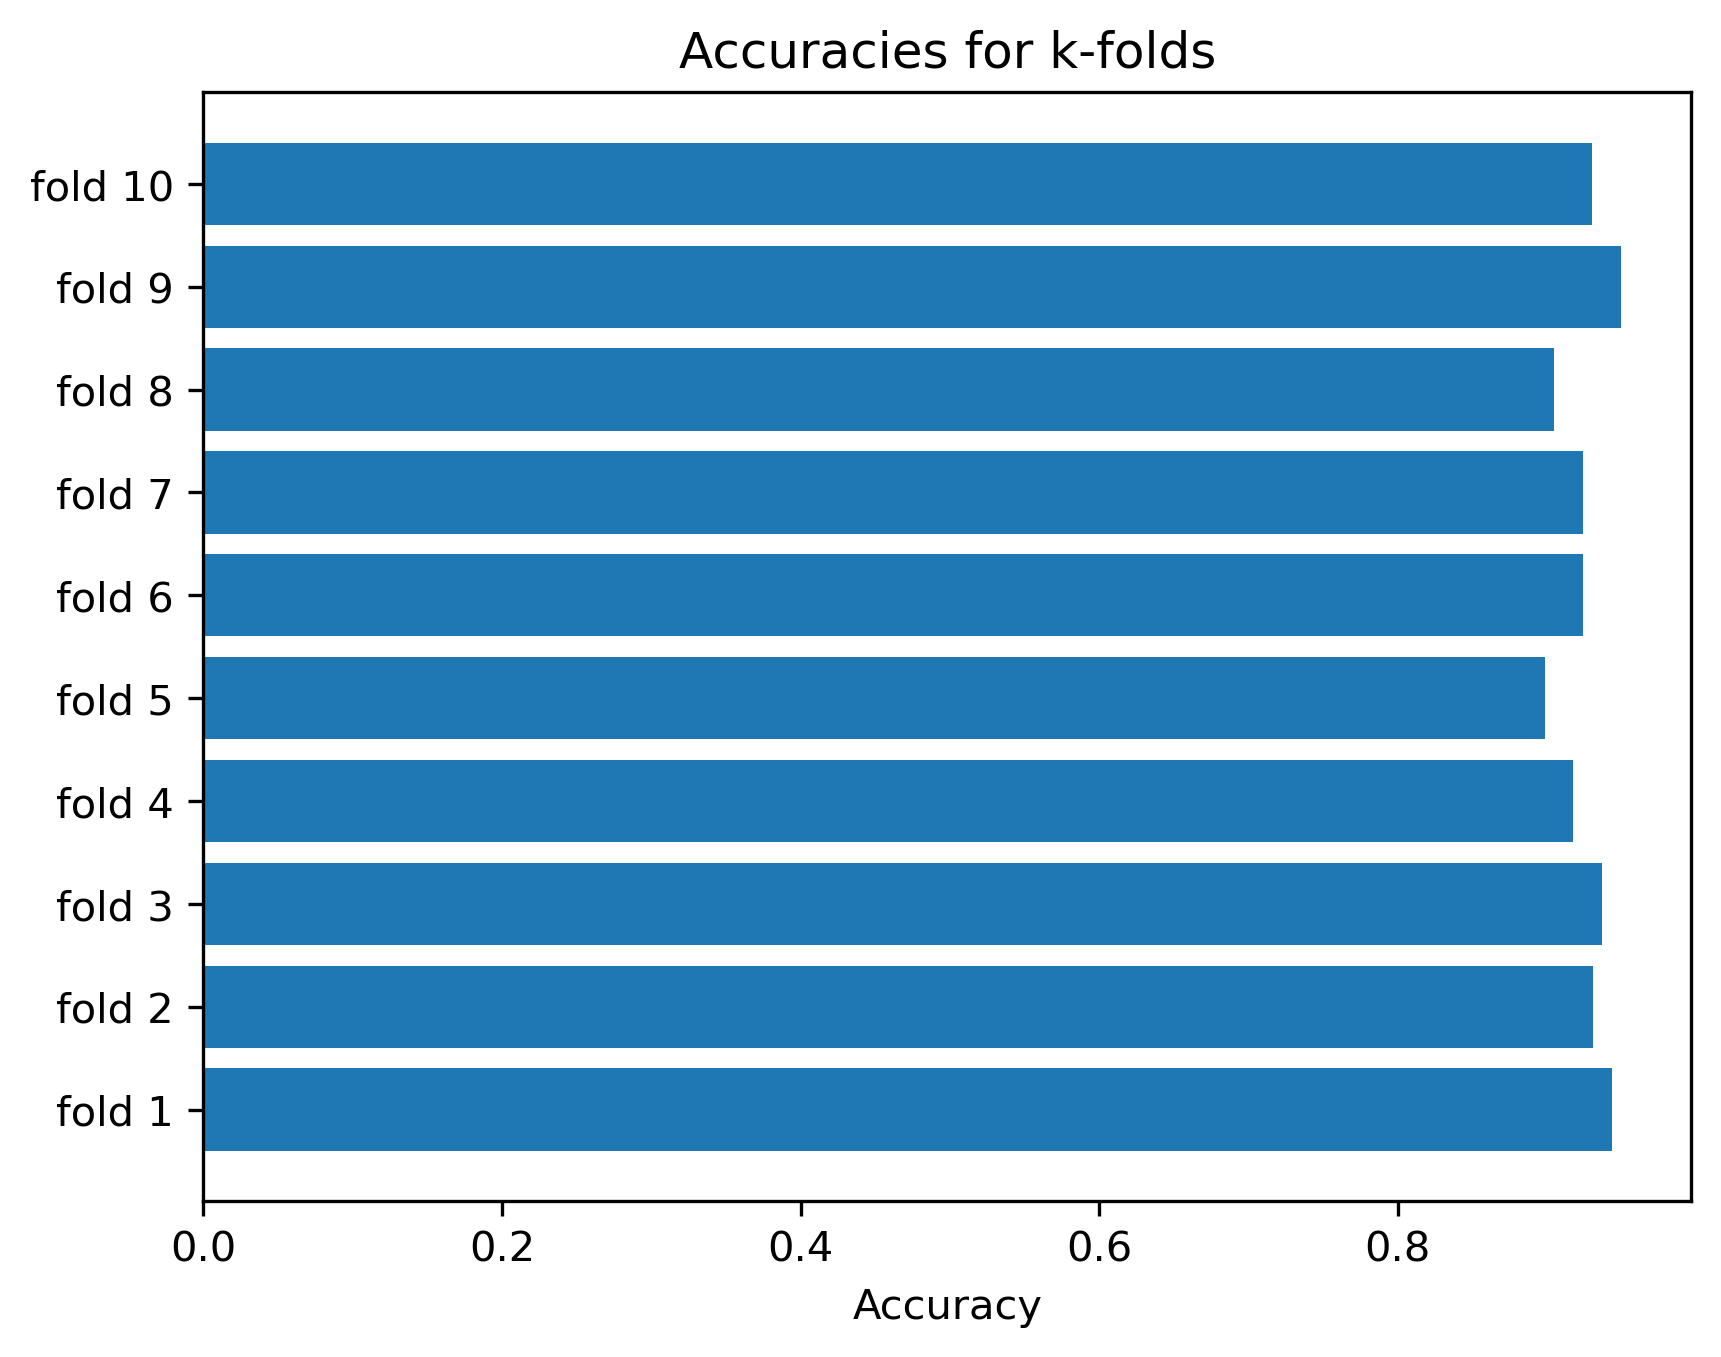

In [24]:
_, ax = plt.subplots(dpi=300)
ax.barh(
    [f"fold {x}" for x in range(1, k_folds+1)],
    scores["test_accuracy"]
)
ax.set_title("Accuracies for k-folds")
ax.set_xlabel("Accuracy")
plt.show()

As we can see, the accuracy does depend on the actual split of the data. This effect is particularly strong in small or very heterogeneous datasets where.